# GRU4Rec: Session-based Recommendations with Recurrent Neural Networks

## Paper

Session-based Recommendations with Recurrent Neural Networks

Published in ICLR 2016

---

## Objective

Implement GRU4Rec from scratch using MovieLens-100K.

Unlike collaborative filtering and graph-based recommendation,
GRU4Rec models the **order of user interactions** and predicts the
next item in a sequence.

---

## Pipeline

MovieLens

↓

Sort by Timestamp

↓

User Sequences

↓

Sliding Window

↓

Padding

↓

Embedding Layer

↓

GRU

↓

Hidden State

↓

Linear Layer

↓

Next Item Prediction

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    roc_curve
)

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import (
    Dataset,
    DataLoader
)

torch.manual_seed(42)
np.random.seed(42)

In [2]:
ratings = pd.read_csv(

    "../data/u.data",

    sep="\t",

    names=[
        "user_id",
        "movie_id",
        "rating",
        "timestamp"
    ]

)

ratings.head()

,user_id,movie_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [3]:
ratings.head(20)

,user_id,movie_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596
5,298,474,4,884182806
6,115,265,2,881171488
7,253,465,5,891628467
8,305,451,3,886324817
9,6,86,3,883603013


In [4]:
print("Shape :", ratings.shape)

print()

print(ratings.info())

print()

print("Users :", ratings.user_id.nunique())

print("Movies :", ratings.movie_id.nunique())

Shape : (100000, 4)

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   user_id    100000 non-null  int64
 1   movie_id   100000 non-null  int64
 2   rating     100000 non-null  int64
 3   timestamp  100000 non-null  int64
dtypes: int64(4)
memory usage: 3.1 MB
None

Users : 943
Movies : 1682


In [5]:
ratings = ratings.sort_values(

    by=[

        "user_id",

        "timestamp"

    ]

).reset_index(

    drop=True

)

ratings.head(20)

,user_id,movie_id,rating,timestamp
0,1,168,5,874965478
1,1,172,5,874965478
2,1,165,5,874965518
3,1,156,4,874965556
4,1,196,5,874965677
5,1,166,5,874965677
6,1,187,4,874965678
7,1,14,5,874965706
8,1,250,4,874965706
9,1,127,5,874965706


In [6]:
user_mapping = {

    u:i

    for i, u in enumerate(

        ratings.user_id.unique()

    )

}

movie_mapping = {

    m:i

    for i, m in enumerate(

        ratings.movie_id.unique()

    )

}

ratings["user_id"] = ratings.user_id.map(

    user_mapping

)

ratings["movie_id"] = (
    ratings["movie_id"]
    .map(movie_mapping)
    + 1
)
# preserving 0 for padding

In [7]:
ratings.head(20)

,user_id,movie_id,rating,timestamp
0,0,1,5,874965478
1,0,2,5,874965478
2,0,3,5,874965518
3,0,4,4,874965556
4,0,5,5,874965677
5,0,6,5,874965677
6,0,7,4,874965678
7,0,8,5,874965706
8,0,9,4,874965706
9,0,10,5,874965706


In [8]:
NUM_USERS = ratings.user_id.nunique()

NUM_MOVIES = ratings.movie_id.nunique()

print("Users :", NUM_USERS)

print("Movies :", NUM_MOVIES)

Users : 943
Movies : 1682


In [9]:
user_sequences = (

    ratings

    .groupby(

        "user_id"

    )["movie_id"]

    .apply(list)

)

In [10]:
user_sequences.head()

user_id
0    [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...
1    [273, 251, 274, 275, 276, 277, 278, 279, 280, ...
2    [309, 307, 317, 318, 126, 319, 280, 320, 321, ...
3    [251, 276, 309, 345, 255, 280, 349, 347, 356, ...
4    [127, 250, 363, 40, 364, 365, 17, 9, 38, 204, ...
Name: movie_id, dtype: object

In [11]:
sequence_lengths = user_sequences.apply(len)

sequence_lengths.describe()

count    943.000000
mean     106.044539
std      100.931743
min       20.000000
25%       33.000000
50%       65.000000
75%      148.000000
max      737.000000
Name: movie_id, dtype: float64

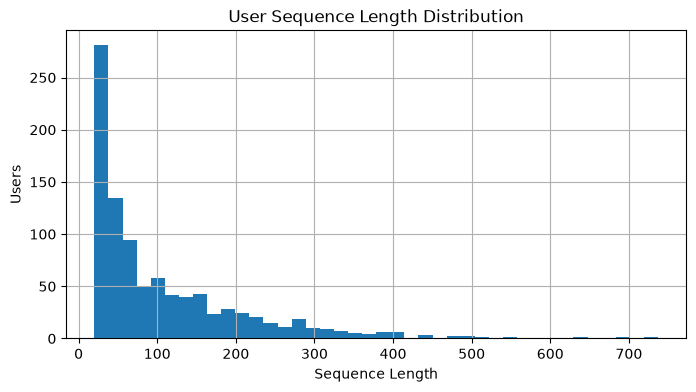

In [12]:
plt.figure(

    figsize=(8,4)

)

plt.hist(

    sequence_lengths,

    bins=40

)

plt.xlabel(

    "Sequence Length"

)

plt.ylabel(

    "Users"

)

plt.title(

    "User Sequence Length Distribution"

)

plt.grid(True)

plt.show()

## creating training samples
```
a->b->c->d
splitted into
a->b
a->b->c
a->b->c->d
```

In [13]:
train_sequences = []

targets = []

for sequence in user_sequences:

    if len(sequence) < 2:
        continue

    for i in range(1, len(sequence)):

        train_sequences.append(
            sequence[:i]
        )

        targets.append(
            sequence[i]
        )

In [14]:
print("Training Samples :", len(train_sequences))

print("Targets :", len(targets))

Training Samples : 99057
Targets : 99057


In [15]:
for i in range(5):

    print(

        "Input :",

        train_sequences[i]

    )

    print(

        "Target:",

        targets[i]

    )

    print("-"*40)

Input : [1]
Target: 2
----------------------------------------
Input : [1, 2]
Target: 3
----------------------------------------
Input : [1, 2, 3]
Target: 4
----------------------------------------
Input : [1, 2, 3, 4]
Target: 5
----------------------------------------
Input : [1, 2, 3, 4, 5]
Target: 6
----------------------------------------


In [16]:
max_length = max(

    len(sequence)

    for sequence in train_sequences

)

print(

    "Maximum Length:",

    max_length
)

print("we are inspecting it so the we can pad the sequences to the same length for batch processing.")

Maximum Length: 736
we are inspecting it so the we can pad the sequences to the same length for batch processing.


In [17]:
# shall we pad the sequences to the same length for batch processing? 
# no because it will be inefficient to pad all to 736 -> 64 rather we will take account of only recent items may be 50 or more or less
MAX_LEN = 50

In [18]:
train_sequences = [

    sequence[-MAX_LEN:]

    for sequence in train_sequences

]
# we are just keeping the last 50 items in the sequence for training, as they are more relevant for predicting the next item.

In [19]:
len(train_sequences), len(targets)

(99057, 99057)

In [20]:
print(

    train_sequences[432]

)

print(

    len(train_sequences[432])

)

[127, 250, 363, 40, 364, 365, 17, 9, 38, 204, 243, 13, 366, 30, 367, 368, 369, 113, 370, 203, 90, 14, 12, 18, 371]
25


In [21]:
PAD_TOKEN = 0

padded_sequences = []

for sequence in train_sequences:

    padding = [PAD_TOKEN] * (MAX_LEN - len(sequence))

    padded = padding + sequence

    padded_sequences.append(padded)

In [22]:
print(padded_sequences[432])

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 127, 250, 363, 40, 364, 365, 17, 9, 38, 204, 243, 13, 366, 30, 367, 368, 369, 113, 370, 203, 90, 14, 12, 18, 371]


In [23]:
padded_sequences = np.array(

    padded_sequences,

    dtype=np.int64

)

targets = np.array(

    targets,

    dtype=np.int64

)

In [24]:
print(padded_sequences.shape)

print(targets.shape)

(99057, 50)
(99057,)


In [25]:
for i in range(5):

    print("Sequence")

    print(padded_sequences[i])

    print("Target:", targets[i])

    print("-"*60)

Sequence
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1]
Target: 2
------------------------------------------------------------
Sequence
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 1 2]
Target: 3
------------------------------------------------------------
Sequence
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 1 2 3]
Target: 4
------------------------------------------------------------
Sequence
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 1 2 3 4]
Target: 5
------------------------------------------------------------
Sequence
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 1 2 3 4 5]
Target: 6
------------------------------------------------------------


In [26]:
train_sequences, test_sequences, train_targets, test_targets = train_test_split(
    padded_sequences,
    targets,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print("Train Samples :", len(train_sequences))
print("Test Samples  :", len(test_sequences))

Train Samples : 79245
Test Samples  : 19812


In [27]:
class GRU4RecDataset(Dataset):

    def __init__(self, sequences, targets):

        self.sequences = torch.LongTensor(sequences)
        self.targets = torch.LongTensor(targets)

    def __len__(self):

        return len(self.sequences)

    def __getitem__(self, idx):

        positive = self.targets[idx]

        return (

            self.sequences[idx],

            positive)

In [28]:
train_dataset = GRU4RecDataset(
    train_sequences,
    train_targets
)

test_dataset = GRU4RecDataset(
    test_sequences,
    test_targets
)

In [29]:
BATCH_SIZE = 256

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [30]:
batch_sequences,batch_targets = next(iter(train_loader))

print(batch_sequences.shape)
print(batch_targets.shape)

torch.Size([256, 50])


torch.Size([256])


In [31]:
print("Input Sequence")
print(batch_sequences[0])

print()

print("Target Movie")
print(batch_targets[0])

Input Sequence
tensor([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0, 344, 276, 303, 321, 309, 126, 282])

Target Movie
tensor(544)


In [32]:
class GRU4Rec(nn.Module):

    def __init__(

        self,

        num_items,

        embedding_dim=128,

        hidden_size=128,

        num_layers=1

    ):

        super().__init__()

        self.embedding = nn.Embedding(

            num_embeddings=num_items + 1,

            embedding_dim=embedding_dim,

            padding_idx=PAD_TOKEN

        )

        self.gru = nn.GRU(

            input_size=embedding_dim,

            hidden_size=hidden_size,

            num_layers=num_layers,

            batch_first=True

        )

    def forward(

        self,

        sequences

    ):

        embeddings = self.embedding(

            sequences

        )

        _, hidden = self.gru(

            embeddings

        )

        hidden = hidden[-1]

        hidden = F.normalize(hidden, dim=1)

        return hidden

In [33]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [34]:
model = GRU4Rec(

    num_items=NUM_MOVIES,

    embedding_dim=128,

    hidden_size=128,

    num_layers=1

).to(device)

In [35]:
model

GRU4Rec(
  (embedding): Embedding(1683, 128, padding_idx=0)
  (gru): GRU(128, 128, batch_first=True)
)

In [36]:
batch_sequences, batch_targets = next(

    iter(train_loader)

)

batch_sequences = batch_sequences.to(device)

batch_targets = batch_targets.to(device)

hidden = model(

    batch_sequences


)

print(hidden.shape)

torch.Size([256, 128])


In [37]:
criterion = nn.CrossEntropyLoss()

In [38]:
optimizer = torch.optim.Adam(

    model.parameters(),

    lr=0.001,

    weight_decay=1e-5

)

In [39]:
NUM_EPOCHS = 10

train_losses = []

train_accuracies = []

for epoch in range(NUM_EPOCHS):

    model.train()

    running_loss = 0.0

    correct = 0

    total = 0

    for sequence, positive in train_loader:

        sequence = sequence.to(device)

        positive = positive.to(device)

        optimizer.zero_grad()

        hidden = model(sequence)

        positive_embedding = model.embedding(
            positive
        )

        positive_embedding = F.normalize(
            positive_embedding,
            dim=1
        )

        scores = torch.matmul(
            hidden,
            positive_embedding.T
        )

        labels = torch.arange(
            scores.size(0),
            device=device
        )

        loss = criterion(
            scores,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        predictions = scores.argmax(dim=1)

        correct += (
            predictions == labels
            ).sum().item()

        total += positive.size(0)

    epoch_loss = running_loss / len(train_loader)

    epoch_accuracy = correct / total

    train_losses.append(epoch_loss)

    train_accuracies.append(epoch_accuracy)

    print(

        f"Epoch {epoch+1:2d}/{NUM_EPOCHS}"

        f" | Loss = {epoch_loss:.4f}"

        f" | Accuracy = {epoch_accuracy:.4f}"

    )

Epoch  1/10 | Loss = 5.5188 | Accuracy = 0.0084
Epoch  2/10 | Loss = 5.4469 | Accuracy = 0.0171
Epoch  3/10 | Loss = 5.3847 | Accuracy = 0.0207
Epoch  4/10 | Loss = 5.3234 | Accuracy = 0.0218
Epoch  5/10 | Loss = 5.2653 | Accuracy = 0.0227
Epoch  6/10 | Loss = 5.2112 | Accuracy = 0.0235
Epoch  7/10 | Loss = 5.1633 | Accuracy = 0.0240
Epoch  8/10 | Loss = 5.1222 | Accuracy = 0.0250
Epoch  9/10 | Loss = 5.0895 | Accuracy = 0.0254
Epoch 10/10 | Loss = 5.0632 | Accuracy = 0.0265


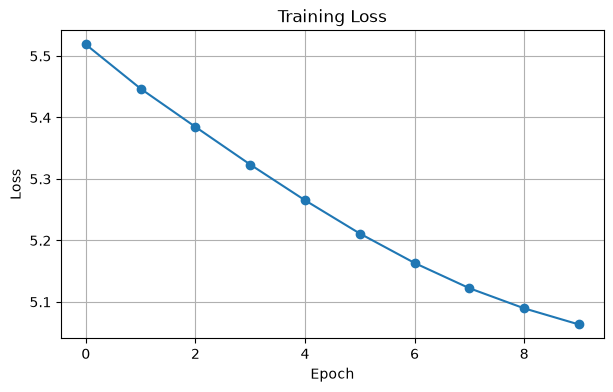

In [40]:
plt.figure(figsize=(7,4))

plt.plot(

    train_losses,

    marker="o"

)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training Loss")

plt.grid(True)

plt.show()

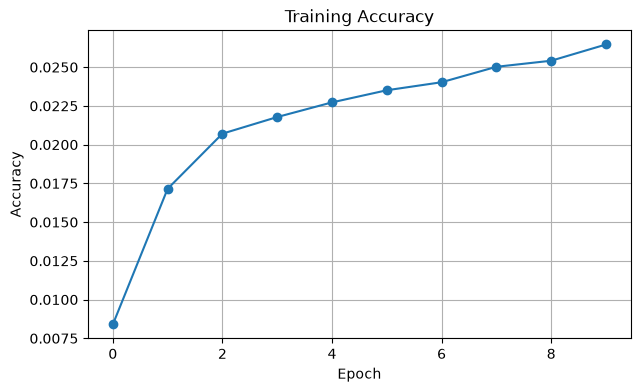

In [41]:
plt.figure(figsize=(7,4))

plt.plot(

    train_accuracies,

    marker="o"

)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Training Accuracy")

plt.grid(True)

plt.show()

In [42]:
import math

def hit_rate_at_k(topk, targets):

    hits = 0

    for prediction, target in zip(topk, targets):

        if target.item() in prediction:

            hits += 1

    return hits / len(targets)

def ndcg_at_k(topk, targets):

    ndcg = 0.0

    for prediction, target in zip(topk, targets):

        prediction = prediction.tolist()

        target = target.item()

        if target in prediction:

            rank = prediction.index(target)

            ndcg += 1 / math.log2(rank + 2)

    return ndcg / len(targets)

In [43]:
model.eval()

all_movie_embeddings = model.embedding.weight

all_movie_embeddings = F.normalize(
    all_movie_embeddings,
    dim=1
)

K = 10

all_topk = []

all_targets = []

with torch.no_grad():

    for sequence, positive in test_loader:

        sequence = sequence.to(device)

        positive = positive.to(device)

        hidden = model(sequence)

        scores = torch.matmul(
            hidden,
            all_movie_embeddings.T
        )

        # Never recommend padding
        scores[:, PAD_TOKEN] = -1e9

        # Mask movies already seen in the input sequence
        for i in range(sequence.size(0)):

            history = sequence[i]

            history = history[history != PAD_TOKEN]

            scores[i, history] = -1e9

        topk = torch.topk(
            scores,
            K,
            dim=1
        ).indices

        all_topk.extend(topk.cpu())

        all_targets.extend(positive.cpu())

In [44]:
hr10 = hit_rate_at_k(
    all_topk,
    all_targets
)

ndcg10 = ndcg_at_k(
    all_topk,
    all_targets
)

print(f"HitRate@10 : {hr10:.4f}")

print(f"NDCG@10 : {ndcg10:.4f}")

HitRate@10 : 0.1169
NDCG@10 : 0.0577
